# Single Heston and Double Heston — validated NSE results

This notebook displays the locked Single-Heston and Double-Heston results for the NSE power-sector option dataset. It **does not invent, interpolate, or replace observations**. It reads the audited result artifacts already produced by the project, verifies the locked source hash, recalculates headline metrics from row-level predictions, and renders comparison graphs.

Important interpretation:

- Parameter selection used training/validation data and was frozen before the historical test calculation.
- The identical comparison contains 8,814 rows. Four additional Double-Heston rows produced invalid implied volatilities; they are disclosed separately and are not imputed.
- The historical test range was viewed during earlier model development, so it is not pristine final-holdout evidence.
- Scoring is conditional on the realized target-session spot and listed strike/expiry coordinates. This is not a pure pre-market forecast of future spot or future contracts.
- A dashed 45° line in an actual-versus-forecast chart is only the ideal-reference line; it is not a fitted model line.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

# The notebook is designed to run from the project root in VS Code.
ROOT = Path.cwd().resolve()
if not (ROOT / "outputs" / "heston_handoff").exists():
    for candidate in [ROOT.parent, Path.home() / "Documents" / "Options pricing"]:
        if (candidate / "outputs" / "heston_handoff").exists():
            ROOT = candidate.resolve()
            break
if not (ROOT / "outputs" / "heston_handoff").exists():
    raise FileNotFoundError("Run this notebook from the 'Options pricing' project directory.")

LOCKED_INPUT_SHA256 = "a8a56dd7b17074d8fa32f88936c8b404456f22f296d9dc4665faf3b13621f1d3"
PATHS = {
    "model_input": ROOT / "outputs/019fc8a0/model_input_option_prices.csv",
    "audit_summary": ROOT / "outputs/heston_handoff/independent_heston_audit_summary.json",
    "audit_checks": ROOT / "outputs/heston_handoff/independent_heston_audit_checks.csv",
    "single_parameters": ROOT / "outputs/heston_handoff/single_heston_selected_parameter_catalog.csv",
    "double_parameters": ROOT / "outputs/heston_handoff/double_heston_selected_parameter_catalog.csv",
    "comparison_summary": ROOT / "outputs/single_double_heston_comparison/single_double_summary.json",
    "metrics": ROOT / "outputs/single_double_heston_comparison/single_double_test_metrics.csv",
    "predictions": ROOT / "outputs/single_double_heston_comparison/single_double_identical_test_predictions.csv",
    "invalid_double_rows": ROOT / "outputs/single_double_heston_comparison/double_heston_test_prediction_failures.csv",
    "integrity": ROOT / "outputs/single_double_heston_comparison/single_double_integrity_checks.csv",
    "single_controlled": ROOT / "outputs/single_heston/single_heston_controlled_tests.json",
    "double_controlled": ROOT / "outputs/single_double_heston_comparison/double_heston_controlled_tests.json",
    "postfit_summary": ROOT / "outputs/double_heston_stability_optimized/optimized_double_heston_summary.json",
    "postfit_rows": ROOT / "outputs/double_heston_stability_optimized/single_old_double_optimized_double_identical_rows.csv",
    "postfit_integrity": ROOT / "outputs/double_heston_stability_optimized/optimized_double_heston_integrity_checks.csv",
    "train_cv_summary": ROOT / "outputs/double_heston_train_cv_optimized/train_cv_optimized_double_heston_summary.json",
    "train_cv_rows": ROOT / "outputs/double_heston_train_cv_optimized/single_old_double_train_cv_double_identical_rows.csv",
    "train_cv_integrity": ROOT / "outputs/double_heston_train_cv_optimized/train_cv_double_heston_integrity_checks.csv",
    "state_scale_summary": ROOT / "outputs/double_heston_state_scale_audit/state_scale_audit_summary.json",
    "state_scale_rows": ROOT / "outputs/double_heston_state_scale_audit/state_scaled_double_heston_test_predictions.csv",
    "state_scale_integrity": ROOT / "outputs/double_heston_state_scale_audit/state_scale_integrity_checks.csv",
}

missing = [str(path) for path in PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required project artifacts:\n" + "\n".join(missing))

print(f"Project root: {ROOT}")
print(f"Python: {platform.python_version()} | pandas: {pd.__version__} | NumPy: {np.__version__}")

Project root: /Users/dhruvaambhaikar/Documents/Options pricing
Python: 3.14.5 | pandas: 3.0.3 | NumPy: 2.4.6


## 1. Authenticity and independent integrity checks

The source file is hashed byte-for-byte before any result is displayed. The audit evidence is loaded from the independent handoff audit, not reconstructed from narrative claims.

In [2]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def passed(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().eq("true")


observed_sha256 = sha256_file(PATHS["model_input"])
audit_summary = json.loads(PATHS["audit_summary"].read_text())
comparison_summary = json.loads(PATHS["comparison_summary"].read_text())
audit_checks = pd.read_csv(PATHS["audit_checks"])
integrity_checks = pd.read_csv(PATHS["integrity"])

assert observed_sha256 == LOCKED_INPUT_SHA256, "Locked NSE model-input hash mismatch"
assert observed_sha256 == audit_summary["input_sha256"] == comparison_summary["input_sha256"]
assert len(audit_checks) == audit_summary["checks_total"] == 60
assert passed(audit_checks["passed"]).all()
assert passed(integrity_checks["passed"]).all()
assert audit_summary["critical_failures"] == 0

authenticity = pd.DataFrame(
    [
        ["Locked model-input SHA-256", observed_sha256],
        ["Independent checks passed", f"{audit_summary['checks_passed']} / {audit_summary['checks_total']}"],
        ["Critical failures", audit_summary["critical_failures"]],
        ["Warnings/limitations recorded", audit_summary["warnings_recorded"]],
        ["Audit verdict", audit_summary["verdict"]],
        ["Identical finite comparison rows", comparison_summary["common_finite_test_rows"]],
        ["Documented invalid Double-Heston rows", comparison_summary["double_heston_invalid_test_rows"]],
    ],
    columns=["Evidence", "Observed value"],
)
display(authenticity)

,Evidence,Observed value
0,Locked model-input SHA-256,a8a56dd7b17074d8fa32f88936c8b404456f22f296d9dc...
1,Independent checks passed,60 / 60
2,Critical failures,0
3,Warnings/limitations recorded,9
4,Audit verdict,VALIDATED_WITH_DISCLOSED_LIMITATIONS
5,Identical finite comparison rows,8814
6,Documented invalid Double-Heston rows,4


## 2. Selected parameters

These are the per-stock parameters selected using training/validation evidence. For Double Heston, the ten displayed values comprise five slow-factor and five fast-factor values, including each factor's training-median initial variance. Boundary proximity is disclosed later as an identifiability warning.

In [3]:
single_params = pd.read_csv(PATHS["single_parameters"])
double_params = pd.read_csv(PATHS["double_parameters"])

single_columns = [
    "symbol", "selected_candidate", "kappa", "theta", "sigma", "rho",
    "v0_training_median", "validation_iv_rmse", "training_last_date",
]
display(Markdown("### Single Heston — 5 parameters per stock"))
display(single_params[single_columns].sort_values("symbol").reset_index(drop=True))

double_slow = [
    "symbol", "selected_candidate", "kappa_slow", "theta_slow", "sigma_slow",
    "rho_slow", "v0_slow_training_median", "training_last_date",
]
double_fast = [
    "symbol", "selected_candidate", "kappa_fast", "theta_fast", "sigma_fast",
    "rho_fast", "v0_fast_training_median", "training_last_date",
]
display(Markdown("### Double Heston — slow factor (5 of 10 parameters)"))
display(double_params[double_slow].sort_values("symbol").reset_index(drop=True))
display(Markdown("### Double Heston — fast factor (5 of 10 parameters)"))
display(double_params[double_fast].sort_values("symbol").reset_index(drop=True))

### Single Heston — 5 parameters per stock

,symbol,selected_candidate,kappa,theta,sigma,rho,v0_training_median,validation_iv_rmse,training_last_date
0,ADANIENSOL,half_a,9.996663,0.402712,2.822393,-0.173073,0.151467,0.049179,2026-01-29
1,ADANIGREEN,half_a,3.981365,0.999666,2.806315,-0.074662,0.167640,0.077256,2026-01-29
2,ADANIPOWER,main,9.996659,0.560397,3.039316,-0.055311,0.325296,0.023363,2026-06-25
3,CESC,half_a,5.506302,0.879373,3.095346,0.134853,0.039588,0.073465,2025-06-06
4,JSWENERGY,main,9.996663,0.426153,2.903374,-0.122050,0.098113,0.044995,2026-01-29
5,NHPC,half_a,9.996663,0.258595,2.261676,0.012605,0.045768,0.042614,2026-01-29
6,NTPC,half_a,9.996663,0.120830,1.545998,-0.094111,0.056204,0.048292,2025-12-15
7,POWERGRID,main,9.996663,0.155460,1.753598,-0.114274,0.029378,0.046688,2025-12-15
8,SJVN,main,9.996443,0.434051,2.930124,-0.001738,0.127590,0.044968,2025-06-06
9,TATAPOWER,main,9.996663,0.175414,1.862741,0.030042,0.064200,0.052841,2025-12-15


### Double Heston — slow factor (5 of 10 parameters)

,symbol,selected_candidate,kappa_slow,theta_slow,sigma_slow,rho_slow,v0_slow_training_median,training_last_date
0,ADANIENSOL,training_half_a,4.755650,0.353849,1.821515,0.567525,0.045393,2025-08-07
1,ADANIGREEN,training_half_a,3.813725,0.171570,1.137861,-0.949681,0.029927,2025-07-03
2,ADANIPOWER,full_start_3,4.998340,0.845936,2.892500,-0.531453,0.078482,2026-05-07
3,CESC,training_half_a,0.051704,0.150343,0.013593,-0.001108,0.005843,2025-05-06
4,JSWENERGY,full_start_1,4.830192,0.336053,1.790856,0.650200,0.026803,2025-06-06
5,NHPC,training_half_a,0.063574,0.135629,0.129923,-0.944830,0.004114,2025-10-20
6,NTPC,training_half_b,4.997313,0.081178,0.895853,0.650635,0.022222,2024-11-07
7,POWERGRID,full_start_3,4.995617,0.153755,1.232828,-0.735950,0.011819,2024-12-23
8,SJVN,full_start_1,1.063320,0.150794,0.563266,-0.949680,0.016240,2025-06-04
9,TATAPOWER,full_start_1,0.051665,0.030971,0.056253,-0.948730,0.006149,2024-10-30


### Double Heston — fast factor (5 of 10 parameters)

,symbol,selected_candidate,kappa_fast,theta_fast,sigma_fast,rho_fast,v0_fast_training_median,training_last_date
0,ADANIENSOL,training_half_a,9.917287,0.206907,2.013533,-0.760214,0.093458,2025-08-07
1,ADANIGREEN,training_half_a,3.927227,0.827656,2.536069,-0.000001,0.095305,2025-07-03
2,ADANIPOWER,full_start_3,9.997614,0.153734,1.208556,0.787016,0.209173,2026-05-07
3,CESC,training_half_a,5.762406,0.847978,3.109475,-0.000000,0.024120,2025-05-06
4,JSWENERGY,full_start_1,9.869913,0.235272,2.142738,-0.691422,0.047385,2025-06-06
5,NHPC,training_half_a,3.360026,0.660608,2.095670,-0.000007,0.030068,2025-10-20
6,NTPC,training_half_b,9.997454,0.066465,1.146657,-0.691616,0.030299,2024-11-07
7,POWERGRID,full_start_3,5.113148,0.109849,1.054234,0.600222,0.013167,2024-12-23
8,SJVN,full_start_1,4.253820,0.842980,2.663736,-0.000002,0.053298,2025-06-04
9,TATAPOWER,full_start_1,9.996651,0.174263,1.856621,-0.000001,0.053749,2024-10-30


## 3. Recalculate the historical comparison

All headline metrics below are recalculated from the 8,814 identical finite option rows. No model receives extra rows in this comparison.

In [4]:
date_columns = ["trade_date", "expiry_date", "origin_date", "target_date"]
pred = pd.read_csv(PATHS["predictions"], parse_dates=date_columns)
saved_metrics = pd.read_csv(PATHS["metrics"])

required = {"row_key", "symbol", "market_iv", "single_heston_iv", "double_heston_iv", "target_date"}
assert required.issubset(pred.columns)
assert len(pred) == comparison_summary["common_finite_test_rows"] == 8_814
assert pred["row_key"].is_unique
assert np.isfinite(pred[["market_iv", "single_heston_iv", "double_heston_iv"]].to_numpy()).all()


def score(actual: pd.Series, forecast: pd.Series) -> dict:
    actual_array = actual.to_numpy(dtype=float)
    forecast_array = forecast.to_numpy(dtype=float)
    error = forecast_array - actual_array
    rmse = float(np.sqrt(np.mean(error**2)))
    mae = float(np.mean(np.abs(error)))
    bias = float(np.mean(error))
    denominator = float(np.sum((actual_array - actual_array.mean()) ** 2))
    r2 = float(1 - np.sum(error**2) / denominator)
    slope = float(np.polyfit(actual_array, forecast_array, 1)[0])
    return {"rows": len(actual_array), "IV RMSE": rmse, "IV MAE": mae, "IV bias": bias, "IV R²": r2, "forecast/actual slope": slope}


recalculated = pd.DataFrame(
    {
        "Single Heston": score(pred["market_iv"], pred["single_heston_iv"]),
        "Double Heston": score(pred["market_iv"], pred["double_heston_iv"]),
    }
).T

saved_overall = saved_metrics[saved_metrics["scope"].eq("ALL")].set_index("model")
for model in ["Single Heston", "Double Heston"]:
    assert np.isclose(recalculated.loc[model, "IV RMSE"], saved_overall.loc[model, "iv_rmse"], atol=1e-12)
    assert np.isclose(recalculated.loc[model, "IV R²"], saved_overall.loc[model, "iv_r2"], atol=1e-12)

display(recalculated)
print(f"Historical winner on identical rows: {comparison_summary['historical_model_preference']}")
bootstrap = comparison_summary["cluster_bootstrap_double_minus_single"]
print(
    "Cluster-bootstrap 95% interval for Double minus Single RMSE: "
    f"[{bootstrap['double_minus_single_rmse_low']:.6f}, {bootstrap['high']:.6f}]"
)

,rows,IV RMSE,IV MAE,IV bias,IV R²,forecast/actual slope
Single Heston,"8,814.000000",0.044200,0.027957,-0.004502,0.816578,0.808616
Double Heston,"8,814.000000",0.045510,0.028264,-0.005601,0.805544,0.798658


Historical winner on identical rows: Single Heston
Cluster-bootstrap 95% interval for Double minus Single RMSE: [0.000607, 0.001993]


## 4. Honest Double-Heston parameter-adjustment search

Three additional adjustments were evaluated without allowing their later-period labels to select parameters: post-fit stability regularization, structural refitting with bounds selected inside the original training partition, and a validation-selected multiplier on the two forecast variance states. The same finite row intersection is used below for a direct comparison.

,rows,IV RMSE,IV MAE,IV bias,IV R²,forecast/actual slope
Single Heston,"8,811.000000",0.043978,0.027884,-0.004421,0.818144,0.810084
State-scale candidate,"8,811.000000",0.045229,0.028180,-0.005509,0.807642,0.800342
Retained Double Heston,"8,811.000000",0.045229,0.028180,-0.005509,0.807642,0.800342
Post-fit stability candidate,"8,811.000000",0.049263,0.030942,-0.003856,0.771805,0.784516
Train-CV interior candidate,"8,811.000000",0.049439,0.033281,-0.001385,0.770169,0.779839


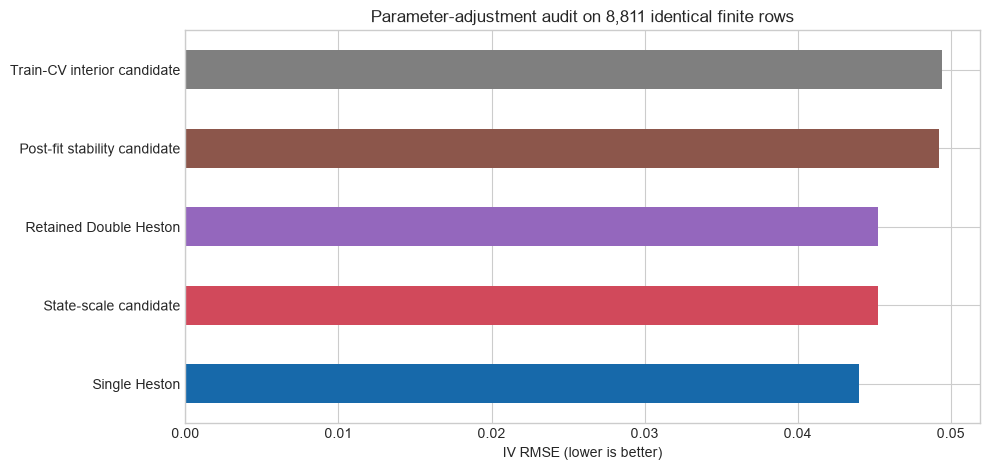

**Interpretation.** No Double-Heston adjustment improved on the retained validation-selected parameters: RMSE is 0.0452, versus 0.0493 after post-fit stability control and 0.0494 after train-only interior refitting. Validation also selected state multiplier 1.0 for every stock, so no state adjustment was accepted.

,Experiment,Structural choice,State choice,Boundary-near stocks,Decision
0,Post-fit stability,training_half_a,theta_share_1d,11.000000,Rejected: higher RMSE
1,Train-only interior refit,per-stock bounds,free two-factor state,0.000000,Rejected: higher RMSE
2,Validation state scaling,retained structural parameters,scale = 1.0 for all stocks,NaN,No adjustment selected


In [5]:
postfit_summary = json.loads(PATHS["postfit_summary"].read_text())
train_cv_summary = json.loads(PATHS["train_cv_summary"].read_text())
state_scale_summary = json.loads(PATHS["state_scale_summary"].read_text())

for check_path in [PATHS["postfit_integrity"], PATHS["train_cv_integrity"], PATHS["state_scale_integrity"]]:
    additional_checks = pd.read_csv(check_path)
    assert passed(additional_checks["passed"]).all(), f"Failed check in {check_path}"

postfit_rows = pd.read_csv(PATHS["postfit_rows"], usecols=["row_key", "optimized_double_iv"]).rename(
    columns={"optimized_double_iv": "postfit_stability_iv"}
)
train_cv_rows = pd.read_csv(PATHS["train_cv_rows"], usecols=["row_key", "optimized_double_iv"]).rename(
    columns={"optimized_double_iv": "train_cv_interior_iv"}
)
state_scale_rows = pd.read_csv(PATHS["state_scale_rows"], usecols=["row_key", "scaled_double_iv"])

search_common = (
    pred[["row_key", "market_iv", "single_heston_iv", "double_heston_iv"]]
    .merge(postfit_rows, on="row_key", validate="one_to_one")
    .merge(train_cv_rows, on="row_key", validate="one_to_one")
    .merge(state_scale_rows, on="row_key", validate="one_to_one")
    .dropna()
)
assert search_common.row_key.is_unique

search_models = {
    "Single Heston": "single_heston_iv",
    "Retained Double Heston": "double_heston_iv",
    "Post-fit stability candidate": "postfit_stability_iv",
    "Train-CV interior candidate": "train_cv_interior_iv",
    "State-scale candidate": "scaled_double_iv",
}
search_scores = pd.DataFrame(
    {label: score(search_common.market_iv, search_common[column]) for label, column in search_models.items()}
).T.sort_values("IV RMSE")
display(search_scores)

axis = search_scores["IV RMSE"].sort_values().plot.barh(
    figsize=(10, 4.8), color=["#1769aa", "#d1495b", "#9467bd", "#8c564b", "#7f7f7f"]
)
axis.set_title(f"Parameter-adjustment audit on {len(search_common):,} identical finite rows")
axis.set_xlabel("IV RMSE (lower is better)")
axis.set_ylabel("")
plt.tight_layout()
plt.show()

retained_rmse = search_scores.loc["Retained Double Heston", "IV RMSE"]
postfit_rmse = search_scores.loc["Post-fit stability candidate", "IV RMSE"]
train_cv_rmse = search_scores.loc["Train-CV interior candidate", "IV RMSE"]
display(
    Markdown(
        f"**Interpretation.** No Double-Heston adjustment improved on the retained validation-selected parameters: RMSE is {retained_rmse:.4f}, versus {postfit_rmse:.4f} after post-fit stability control and {train_cv_rmse:.4f} after train-only interior refitting. Validation also selected state multiplier 1.0 for every stock, so no state adjustment was accepted."
    )
)

adjustment_audit = pd.DataFrame(
    [
        ["Post-fit stability", postfit_summary["selected_recipe"], postfit_summary["selected_state_mode"], postfit_summary["selected_boundary_near_stocks"], "Rejected: higher RMSE"],
        ["Train-only interior refit", "per-stock bounds", "free two-factor state", train_cv_summary["selected_boundary_near_stocks"], "Rejected: higher RMSE"],
        ["Validation state scaling", "retained structural parameters", "scale = 1.0 for all stocks", None, "No adjustment selected"],
    ],
    columns=["Experiment", "Structural choice", "State choice", "Boundary-near stocks", "Decision"],
)
display(adjustment_audit)

## 5. Actual implied volatility versus both models

The faint points are individual option observations. The solid curve is a 20-quantile binned mean, which makes calibration/generalization shape easier to see. The dashed 45° line is the ideal `forecast = actual` reference and therefore has the same angle in both panels by definition.

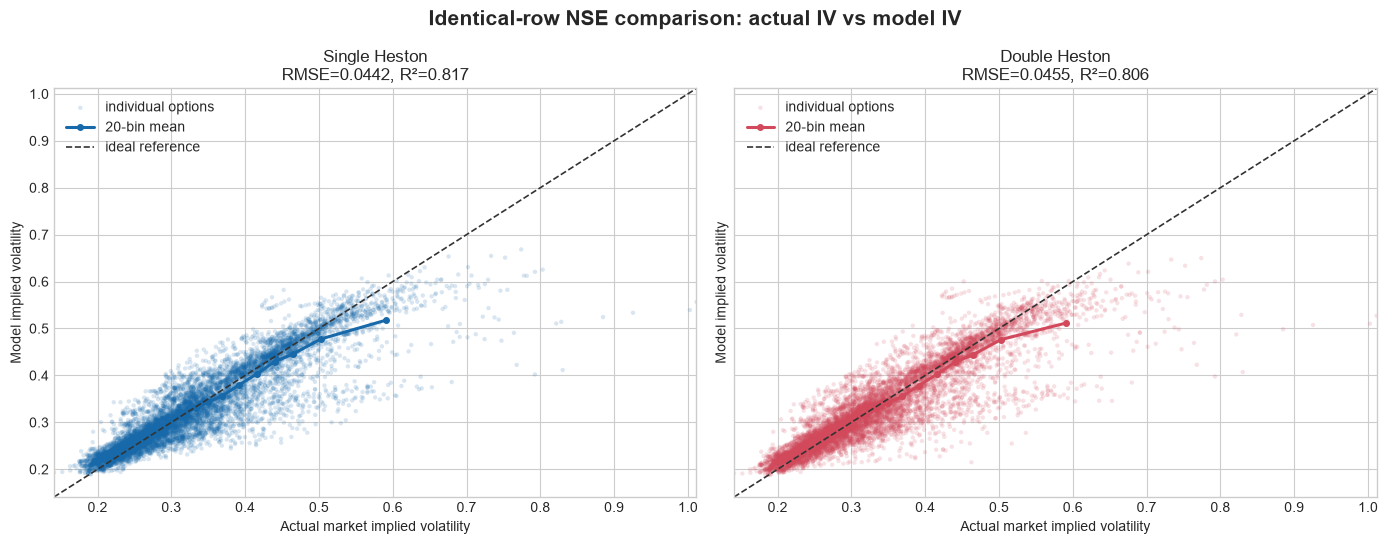

**Interpretation.** Single Heston is closer overall (RMSE 0.0442 versus 0.0455). Both models compress the volatility range: their forecast/actual slopes are 0.809 and 0.799, below the ideal value of 1.

In [6]:
models = [
    ("Single Heston", "single_heston_iv", "#1769aa"),
    ("Double Heston", "double_heston_iv", "#d1495b"),
]
limits = [
    float(pred[["market_iv", "single_heston_iv", "double_heston_iv"]].min().min()),
    float(pred[["market_iv", "single_heston_iv", "double_heston_iv"]].max().max()),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
for axis, (label, column, color) in zip(axes, models):
    axis.scatter(pred["market_iv"], pred[column], s=10, alpha=0.16, color=color, edgecolors="none", label="individual options")
    bins = pd.qcut(pred["market_iv"], q=20, duplicates="drop")
    curve = pred.assign(actual_bin=bins).groupby("actual_bin", observed=True)[["market_iv", column]].mean()
    axis.plot(curve["market_iv"], curve[column], color=color, marker="o", linewidth=2.2, markersize=4, label="20-bin mean")
    axis.plot(limits, limits, "--", color="#333333", linewidth=1.2, label="ideal reference")
    metrics_row = recalculated.loc[label]
    axis.set_title(f"{label}\nRMSE={metrics_row['IV RMSE']:.4f}, R²={metrics_row['IV R²']:.3f}")
    axis.set_xlabel("Actual market implied volatility")
    axis.set_ylabel("Model implied volatility")
    axis.set_xlim(limits)
    axis.set_ylim(limits)
    axis.legend(loc="upper left")

fig.suptitle("Identical-row NSE comparison: actual IV vs model IV", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

display(
    Markdown(
        f'''**Interpretation.** Single Heston is closer overall (RMSE {recalculated.loc['Single Heston', 'IV RMSE']:.4f} versus {recalculated.loc['Double Heston', 'IV RMSE']:.4f}). Both models compress the volatility range: their forecast/actual slopes are {recalculated.loc['Single Heston', 'forecast/actual slope']:.3f} and {recalculated.loc['Double Heston', 'forecast/actual slope']:.3f}, below the ideal value of 1.'''
    )
)

## 6. Stock-level accuracy and a chronological example

The grouped bars compare out-of-sample historical-test RMSE on each stock's identical rows. The chronological chart uses daily cross-sectional mean IV for one editable stock, keeping the Single and Double paths visually separate.

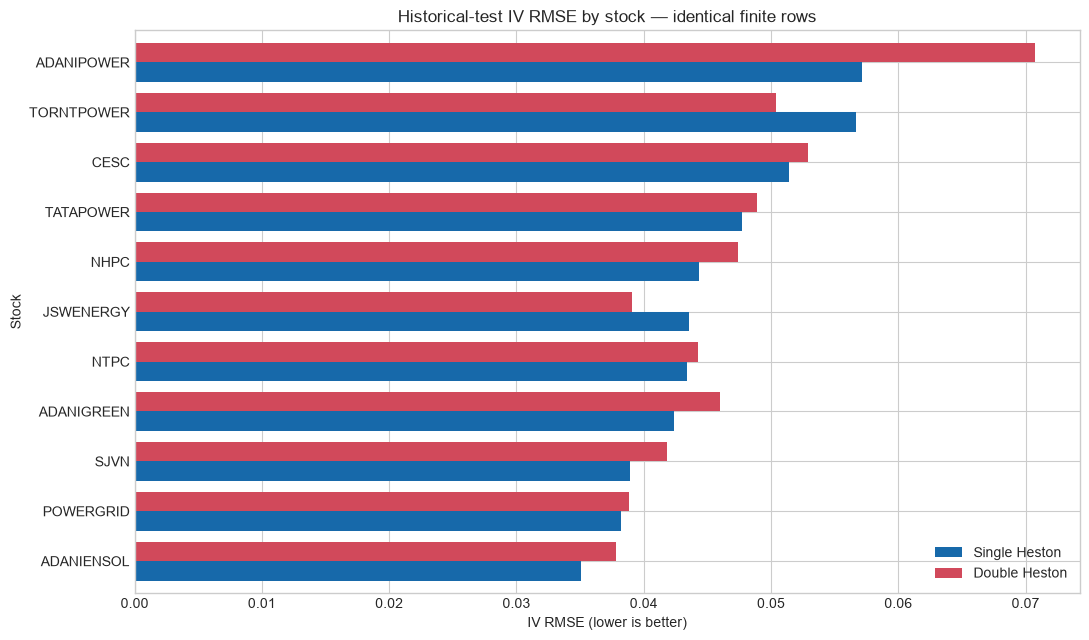

**Interpretation.** Single Heston has lower RMSE for 9 of 11 stocks; Double Heston wins only 2. Shorter bars mean better historical-test accuracy.

model,Double Heston,Single Heston,Double minus Single,Winner
scope,,,,
ADANIENSOL,0.037827,0.035058,0.002770,Single Heston
POWERGRID,0.038862,0.038244,0.000617,Single Heston
SJVN,0.041864,0.038933,0.002931,Single Heston
ADANIGREEN,0.045958,0.042358,0.003599,Single Heston
NTPC,0.044258,0.043370,0.000888,Single Heston
JSWENERGY,0.039108,0.043534,-0.004426,Double Heston
NHPC,0.047366,0.044355,0.003012,Single Heston
TATAPOWER,0.048878,0.047752,0.001127,Single Heston
CESC,0.052918,0.051420,0.001499,Single Heston


Stocks where Double Heston has lower RMSE: JSWENERGY, TORNTPOWER


In [7]:
stock_metrics = saved_metrics[~saved_metrics["scope"].eq("ALL")].copy()
stock_rmse = stock_metrics.pivot(index="scope", columns="model", values="iv_rmse")
stock_rmse["Double minus Single"] = stock_rmse["Double Heston"] - stock_rmse["Single Heston"]
stock_rmse["Winner"] = np.where(stock_rmse["Double minus Single"] < 0, "Double Heston", "Single Heston")
stock_rmse = stock_rmse.sort_values("Single Heston")

axis = stock_rmse[["Single Heston", "Double Heston"]].plot(
    kind="barh", figsize=(11, 6.5), color=["#1769aa", "#d1495b"], width=0.78
)
axis.set_title("Historical-test IV RMSE by stock — identical finite rows")
axis.set_xlabel("IV RMSE (lower is better)")
axis.set_ylabel("Stock")
axis.legend(loc="lower right")
plt.tight_layout()
plt.show()

single_stock_wins = int((stock_rmse["Winner"] == "Single Heston").sum())
double_stock_wins = int((stock_rmse["Winner"] == "Double Heston").sum())
display(Markdown(f"**Interpretation.** Single Heston has lower RMSE for {single_stock_wins} of {len(stock_rmse)} stocks; Double Heston wins only {double_stock_wins}. Shorter bars mean better historical-test accuracy."))

display(stock_rmse)
print("Stocks where Double Heston has lower RMSE:", ", ".join(comparison_summary["double_better_test_rmse_symbols"]))

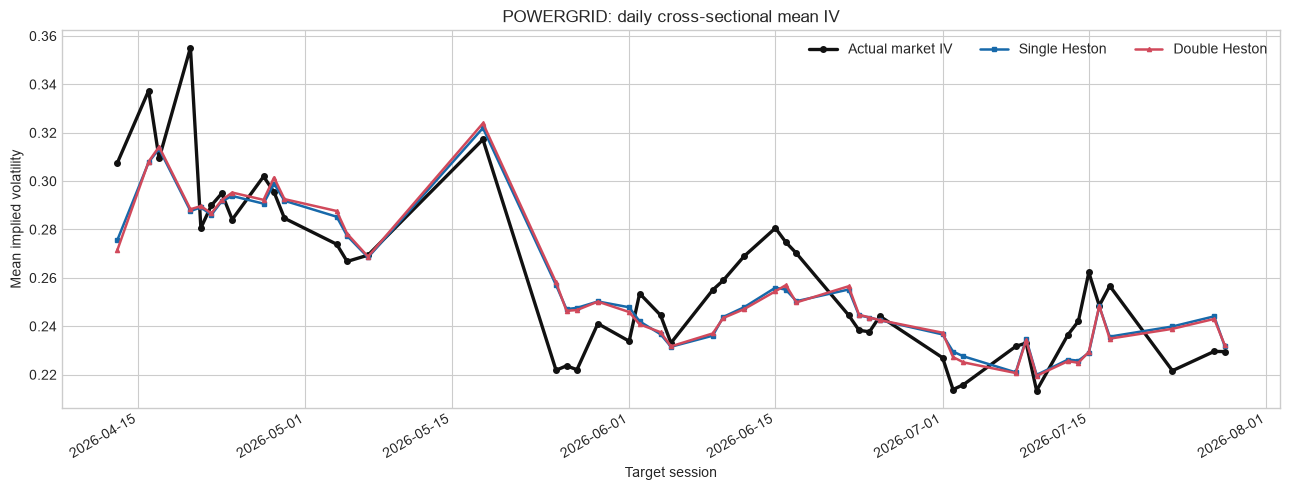

**Interpretation.** For POWERGRID, Single Heston follows the daily mean market IV more closely (daily-mean RMSE 0.0183 versus 0.0184). This averaged view shows session-level tracking, not individual-option accuracy.

In [8]:
# Change this symbol and rerun the cell in VS Code to inspect another stock.
SYMBOL_TO_PLOT = "POWERGRID"
available_symbols = sorted(pred["symbol"].unique())
if SYMBOL_TO_PLOT not in available_symbols:
    raise ValueError(f"Choose one of: {available_symbols}")

daily = (
    pred[pred["symbol"].eq(SYMBOL_TO_PLOT)]
    .groupby("target_date", as_index=False)[["market_iv", "single_heston_iv", "double_heston_iv"]]
    .mean()
)

fig, axis = plt.subplots(figsize=(13, 5))
axis.plot(daily["target_date"], daily["market_iv"], color="#111111", linewidth=2.4, marker="o", markersize=4, label="Actual market IV")
axis.plot(daily["target_date"], daily["single_heston_iv"], color="#1769aa", linewidth=1.8, marker="s", markersize=3, label="Single Heston")
axis.plot(daily["target_date"], daily["double_heston_iv"], color="#d1495b", linewidth=1.8, marker="^", markersize=3, label="Double Heston")
axis.set_title(f"{SYMBOL_TO_PLOT}: daily cross-sectional mean IV")
axis.set_xlabel("Target session")
axis.set_ylabel("Mean implied volatility")
axis.legend(ncol=3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

daily_single_rmse = float(np.sqrt(np.mean((daily["single_heston_iv"] - daily["market_iv"]) ** 2)))
daily_double_rmse = float(np.sqrt(np.mean((daily["double_heston_iv"] - daily["market_iv"]) ** 2)))
daily_winner = "Single Heston" if daily_single_rmse < daily_double_rmse else "Double Heston"
display(Markdown(f"**Interpretation.** For {SYMBOL_TO_PLOT}, {daily_winner} follows the daily mean market IV more closely (daily-mean RMSE {min(daily_single_rmse, daily_double_rmse):.4f} versus {max(daily_single_rmse, daily_double_rmse):.4f}). This averaged view shows session-level tracking, not individual-option accuracy."))

## 7. Invalid-row disclosure and coverage

Invalid Double-Heston values are not replaced with the Single-Heston value, a baseline, zero, or a fabricated estimate. They are excluded from the identical finite-row score and retained in a separate failure file.

In [9]:
invalid_rows = pd.read_csv(PATHS["invalid_double_rows"])
assert len(invalid_rows) == comparison_summary["double_heston_invalid_test_rows"] == 4
assert invalid_rows["row_key"].is_unique
assert invalid_rows["double_heston_iv"].isna().all()
assert set(invalid_rows["row_key"]).isdisjoint(set(pred["row_key"]))

coverage = pd.DataFrame(
    {
        "Measure": ["Source-universe test rows", "Identical finite rows", "Invalid Double-Heston rows", "Finite common coverage"],
        "Value": [
            comparison_summary["test_source_universe_rows"],
            comparison_summary["common_finite_test_rows"],
            comparison_summary["double_heston_invalid_test_rows"],
            comparison_summary["finite_common_test_coverage"],
        ],
    }
)
display(coverage)
display(invalid_rows[["symbol", "trade_date", "expiry_date", "option_type", "strike", "market_iv", "double_heston_price", "double_heston_iv", "row_key"]])

,Measure,Value
0,Source-universe test rows,"8,818.000000"
1,Identical finite rows,"8,814.000000"
2,Invalid Double-Heston rows,4.000000
3,Finite common coverage,0.999546


,symbol,trade_date,expiry_date,option_type,strike,market_iv,double_heston_price,double_heston_iv,row_key
0,NTPC,2026-05-19,2026-05-26,CE,450.000000,0.483856,-0.000009,NaN,NTPC|2026-05-19|2026-05-26|CE|450.00
1,NTPC,2026-06-19,2026-06-30,CE,460.000000,0.500642,-0.000068,NaN,NTPC|2026-06-19|2026-06-30|CE|460.00
2,NTPC,2026-06-22,2026-06-30,CE,460.000000,0.584881,-0.000002,NaN,NTPC|2026-06-22|2026-06-30|CE|460.00
3,NTPC,2026-07-21,2026-07-28,CE,460.000000,0.805036,-0.000013,NaN,NTPC|2026-07-21|2026-07-28|CE|460.00


## 8. Controlled synthetic recovery tests

Synthetic tests are separate from NSE results. They check implementation behavior against known parameters, multiple starting values, and 1% price noise. For Double Heston, the controlled recovery file checks the eight structural parameters; the two time-varying initial variances are state estimates, while all ten selected per-stock values are shown above.

In [10]:
single_controlled = json.loads(PATHS["single_controlled"].read_text())
double_controlled = json.loads(PATHS["double_controlled"].read_text())
assert single_controlled["all_checks_passed"] is True
assert double_controlled["all_checks_passed"] is True
assert single_controlled["synthetic_data_is_separate_from_nse_results"] is True
assert double_controlled["synthetic_data_is_separate_from_nse_results"] is True

single_names = ["kappa", "theta", "sigma", "rho", "v0"]
single_recovery = pd.DataFrame(
    {
        "parameter": single_names,
        "known": single_controlled["known_parameters"],
        "exact recovery": single_controlled["exact_recovered_parameters"],
        "1% noise recovery": single_controlled["noisy_recovered_parameters"],
    }
)
double_names = ["kappa_slow", "theta_slow", "sigma_slow", "rho_slow", "kappa_fast", "theta_fast", "sigma_fast", "rho_fast"]
double_recovery = pd.DataFrame(
    {
        "parameter": double_names,
        "known": double_controlled["known_structural_parameters"],
        "exact recovery": double_controlled["exact_recovered_structural_parameters"],
        "1% noise recovery": double_controlled["noisy_recovered_structural_parameters"],
    }
)

display(Markdown("### Single-Heston controlled recovery"))
display(single_recovery)
display(Markdown("### Double-Heston controlled structural recovery"))
display(double_recovery)

controlled_summary = pd.DataFrame(
    [
        ["Single Heston", single_controlled["exact_price_rmse"], single_controlled["exact_max_relative_parameter_error"], single_controlled["noisy_price_rmse"]],
        ["Double Heston", double_controlled["exact_price_rmse"], double_controlled["exact_max_relative_structural_error"], double_controlled["noisy_price_rmse"]],
    ],
    columns=["model", "exact price RMSE", "exact max relative parameter error", "1% noise price RMSE"],
).set_index("model")
display(controlled_summary)

### Single-Heston controlled recovery

,parameter,known,exact recovery,1% noise recovery
0,kappa,1.800000,1.800000,2.023427
1,theta,0.055000,0.055000,0.055484
2,sigma,0.280000,0.280000,0.307553
3,rho,-0.650000,-0.650000,-0.611159
4,v0,0.070000,0.070000,0.070594


### Double-Heston controlled structural recovery

,parameter,known,exact recovery,1% noise recovery
0,kappa_slow,0.550000,0.550007,0.437170
1,theta_slow,0.035000,0.035000,0.032931
2,sigma_slow,0.130000,0.130000,0.099676
3,rho_slow,-0.550000,-0.549997,-0.708810
4,kappa_fast,3.200000,3.200001,3.861060
5,theta_fast,0.025000,0.025000,0.022405
6,sigma_fast,0.300000,0.300000,0.356160
7,rho_fast,-0.300000,-0.300000,-0.263162


,exact price RMSE,exact max relative parameter error,1% noise price RMSE
model,,,
Single Heston,0.000000,0.000000,0.022329
Double Heston,0.000000,0.000012,0.026107


## 9. Audit warnings and honest conclusion

A passing warning check means the limitation was successfully detected and disclosed; it does not turn the limitation into a strength.

In [11]:
audit_breakdown = (
    audit_checks.assign(passed_flag=passed(audit_checks["passed"]))
    .groupby(["category", "severity"], dropna=False)
    .agg(checks=("check", "size"), passed=("passed_flag", "sum"))
    .reset_index()
)
warnings = audit_checks[audit_checks["severity"].astype(str).str.lower().eq("warning")].copy()
display(audit_breakdown)
display(Markdown("### Recorded warnings and limitations"))
display(warnings[["category", "check", "observed", "detail"]].reset_index(drop=True))

display(
    Markdown(
        f'''
### Evidence-based conclusion

- **Historical preference:** {comparison_summary['historical_model_preference']}.
- **Single-Heston RMSE:** {comparison_summary['single_heston']['iv_rmse']:.6f}; **Double-Heston RMSE:** {comparison_summary['double_heston']['iv_rmse']:.6f} on the same {comparison_summary['common_finite_test_rows']:,} rows.
- The Double-Heston minus Single-Heston bootstrap interval is entirely positive, so this historical sample favors Single Heston.
- Three stability-focused Double-Heston adjustment searches failed to improve RMSE; the validation-selected state multiplier was 1.0 for every stock. The retained Double-Heston catalog above is therefore the least-bad honest Double-Heston choice tested, not a claimed global optimum.
- Every one of the {comparison_summary['candidate_boundary_flags']} Double-Heston candidates is boundary-near. Its parameters should not be described as uniquely identified or globally optimal.
- These are retrospective, conditional historical-test results. Future dates must be locked before arrival for pristine forward validation.
'''
    )
)

,category,severity,checks,passed
0,chronology,critical,5,5
1,constraints,critical,5,5
2,controlled,critical,2,2
3,controlled,warning,2,2
4,coverage,critical,3,3
5,equation,critical,6,6
6,expiry,critical,3,3
7,honesty,warning,2,2
8,leakage,critical,1,1
9,lineage,critical,3,3


### Recorded warnings and limitations

,category,check,observed,detail
0,overfit,double_boundary_near_candidates_recorded,55,A passing evidence check records that every ca...
1,overfit,historical_bootstrap_favors_single_Heston,"95% interval [0.00060695, 0.00199293]",NaN
2,overfit,quadratic_same_day_smile_beats_single_Heston,quadratic=0.014712; Heston=0.030028,NaN
3,overfit,single_half_sample_boundary_flags_recorded,39,NaN
4,honesty,generalized_single_result_labeled_retrospective,retrospective historical-test comparison; the ...,NaN
5,honesty,conditional_evaluation_scope_explicit,['CONDITIONAL_ON_REALIZED_TARGET_SPOT_AND_QUOT...,The evaluation uses realized target spot and l...
6,controlled,single_one_percent_noise_sensitivity_recorded,0.1241260944772804,NaN
7,controlled,double_one_percent_noise_sensitivity_recorded,0.28874634698904245,NaN
8,privacy,raw_machine_artifacts_with_local_paths_identified,['outputs/single_heston_next_day_forecast/para...,Do not share these raw files verbatim; use the...



### Evidence-based conclusion

- **Historical preference:** Single Heston.
- **Single-Heston RMSE:** 0.044200; **Double-Heston RMSE:** 0.045510 on the same 8,814 rows.
- The Double-Heston minus Single-Heston bootstrap interval is entirely positive, so this historical sample favors Single Heston.
- Three stability-focused Double-Heston adjustment searches failed to improve RMSE; the validation-selected state multiplier was 1.0 for every stock. The retained Double-Heston catalog above is therefore the least-bad honest Double-Heston choice tested, not a claimed global optimum.
- Every one of the 55 Double-Heston candidates is boundary-near. Its parameters should not be described as uniquely identified or globally optimal.
- These are retrospective, conditional historical-test results. Future dates must be locked before arrival for pristine forward validation.


## 10. Optional reproducibility commands

The audited pricing and calibration implementations remain in the project `.py` files. Keeping one implementation avoids notebook/script drift. Leave `RERUN_MODELS = False` for instant display of the locked outputs. Set it to `True` only when you intentionally want to regenerate the artifacts; full calibration can take substantial time.

In [12]:
source_files = [
    ROOT / "single_heston.py",
    ROOT / "double_heston.py",
    ROOT / "forecast_single_heston_next_day.py",
    ROOT / "compare_single_double_heston.py",
    ROOT / "optimize_double_heston_stable.py",
    ROOT / "optimize_double_heston_train_cv.py",
    ROOT / "validate_double_heston_state_scaling.py",
    ROOT / "audit_heston_handoff.py",
]
source_manifest = pd.DataFrame(
    [{"file": path.name, "sha256": sha256_file(path), "bytes": path.stat().st_size} for path in source_files]
)
display(source_manifest)

RERUN_MODELS = False
if RERUN_MODELS:
    commands = [
        [sys.executable, "forecast_single_heston_next_day.py"],
        [sys.executable, "compare_single_double_heston.py", "--reuse-candidates"],
        [sys.executable, "audit_heston_handoff.py"],
    ]
    for command in commands:
        print("Running:", " ".join(command))
        subprocess.run(command, cwd=ROOT, check=True)
else:
    print("Locked artifacts displayed. Set RERUN_MODELS = True to regenerate them intentionally.")

,file,sha256,bytes
0,single_heston.py,e265d350db5e90605b2e8f371149a67ed75e22b0400ca1...,39476
1,double_heston.py,fac605a758dc56e873caa43fa05e4ca9d43bae12861322...,8982
2,forecast_single_heston_next_day.py,c8e7c5083d62df79bfc2f5418c6fddabcc8de507a3a164...,33912
3,compare_single_double_heston.py,99eab83249359eac4908ba25dcc6fcc8ab7ad18463ae60...,31146
4,optimize_double_heston_stable.py,67073add3542571cee732d96ae4503f276435fb0b85255...,28502
5,optimize_double_heston_train_cv.py,87b9ad7737d2fb4a59e78d8301c0ff5d0f3bc2e97446ec...,23197
6,validate_double_heston_state_scaling.py,e187d863c885c4be75db8ebe2dac38cd1dcfc16091bdec...,9517
7,audit_heston_handoff.py,d8595db839b95725ead778a424388b3f7e60bad14280b1...,33675


Locked artifacts displayed. Set RERUN_MODELS = True to regenerate them intentionally.
